In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle, small_saw_tooth, small_r_pulse
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, target_function, get_predictions, get_improvement
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_data_rw
from smooth_POD_ROM.plots_paper import Fig3
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

8.030570172000001


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [3]:
def small_saw_tooth(x, mu):
    return saw_tooth(x, mu, w=1/45)

In [4]:
n_x = 5000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 50,
    "n_test": 10,  # 25
    "g": small_saw_tooth, #small_saw_tooth, #saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 250,
    "monitor_convergence": False,
}

In [5]:
def Fig3(x, mu_train, X_train, X_train_s):
    fig = plt.figure(figsize=(page_width_in, page_width_in / 2), facecolor="white")
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    for i in range(len(mu_train)):
        ax1.plot(np.ones_like(x) * mu_train[i], x, X_train[i], "k-", lw=1)
        ax2.plot(np.ones_like(x) * mu_train[i], x, X_train_s[i], "k-", lw=1)
    for ax in (ax1, ax2):
        ax.xaxis.labelpad = -5
        ax.yaxis.labelpad = -5
        xticks = [0.0, 0.2, 0.4, 0.6, 0.8]
        xticks = [0.0, 0.5, 1.0]
        yticks = [0.0, 0.5, 1.0]
        ax.set_xticks(xticks)
        ax.set_yticks(yticks)
        ax.set_zticks([0.5, 1.0])
        ax.tick_params(axis="x", which="major", pad=-5)
        ax.tick_params(axis="y", which="major", pad=-2)
        ax.tick_params(axis="z", which="major", pad=0)
        ax.set_yticklabels(yticks, va="baseline", ha="left")
        for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
            for tick in axis.get_major_ticks():
                # for some reasons it does not match
                tick.label1.set_fontsize(8)
            axis.pane.set_edgecolor("white")

        ax.grid(False)
        ax.set_facecolor("white")
        ax.xaxis.pane.fill = False  # Remove the background pane
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.set_xlabel(r"$\mu$")
        ax.set_ylabel(r"$x$")
    plt.show()

def Fig6(mu_val, eROM, esROM, esROMs):
    fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
    ax.plot(mu_val, eROM, "C0-", label=r"$u_{\mu, rb}$")
    ax.plot(mu_val, esROM, "C1--", label=r"$u_{\mu, rb, S}$")
    ax.plot(mu_val, esROMs, "C2-", label=r"$u_{\mu, rb, SD_{100}}$")
#    ax.plot(mu_val, esROMs2, "C3-", label="$u_{\mu, rb, SD_{1000}}$")
    plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb}}\|_{L_2}$")
    plt.xlabel(r"$\mu$")
    plt.legend()
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 0.4, 21, endpoint=True), minor=True)
    plt.grid(True, which="minor", linestyle="--", lw=0.25)
    plt.grid(True, which="major", linestyle="-")
    plt.xlim(0, 1)
    # plt.show()
    return fig, ax

10


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


250, 0.05050000, 5.00000000, 0.09449577, 0.08078437, 0.04612434, -51.1890
250, 0.08350000, 5.00000000, 0.09449577, 0.08244057, 0.06788922, -28.1563
250, 0.01750000, 5.00000000, 0.09449577, 0.08101847, 0.09139541, -3.2809
250, 0.05050000, 8.33333333, 0.09449577, 0.08078437, 0.05269826, -44.2321
250, 0.05050000, 1.66666667, 0.09449577, 0.08078437, 0.05232216, -44.6302
250, 0.08350000, 1.66666667, 0.09449577, 0.08244057, 0.06347905, -32.8234
250, 0.01750000, 1.66666667, 0.09449577, 0.08101847, 0.11092347, 17.3846
250, 0.06150000, 5.00000000, 0.09449577, 0.08141440, 0.05446746, -42.3599
250, 0.03950000, 5.00000000, 0.09449577, 0.08016418, 0.03978254, -57.9002
250, 0.05050000, 6.11111111, 0.09449577, 0.08078437, 0.04976268, -47.3387
250, 0.05050000, 3.88888889, 0.09449577, 0.08078437, 0.04548358, -51.8671
250, 0.08350000, 8.33333333, 0.09449577, 0.08244057, 0.06593805, -30.2212
250, 0.01750000, 8.33333333, 0.09449577, 0.08101847, 0.05626866, -40.4538
250, 0.03950000, 6.11111111, 0.09449577,

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


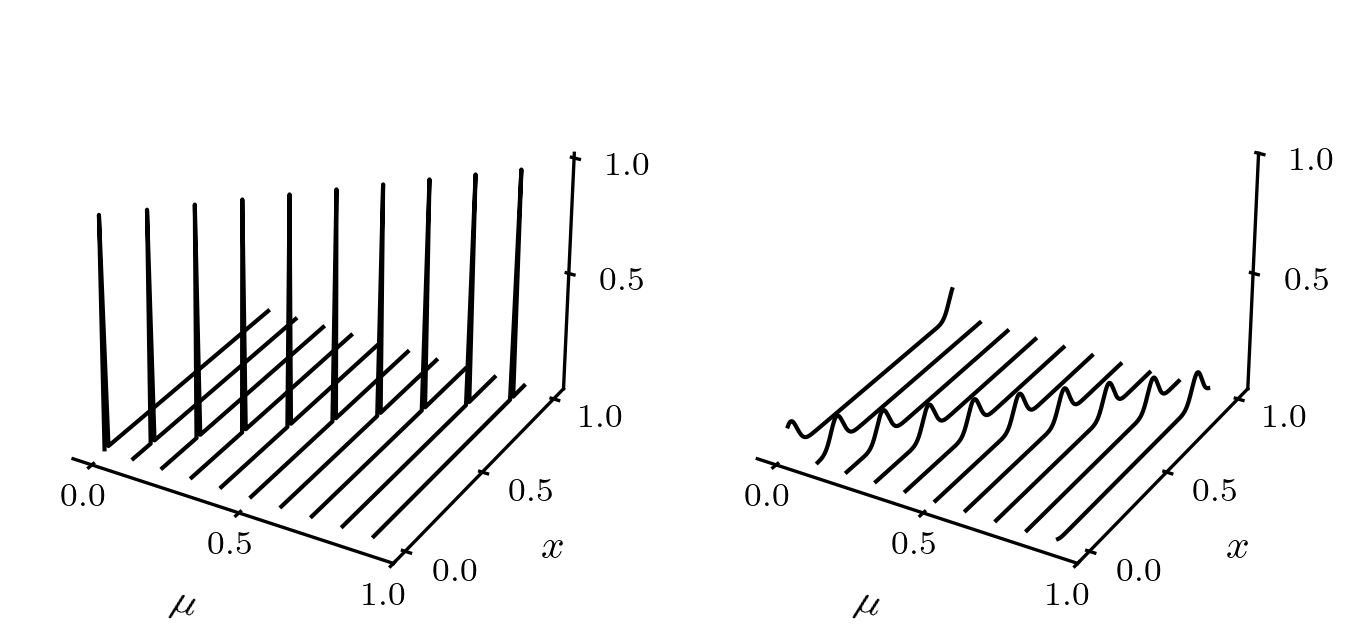

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


average improvement (250 iterations): 61.84


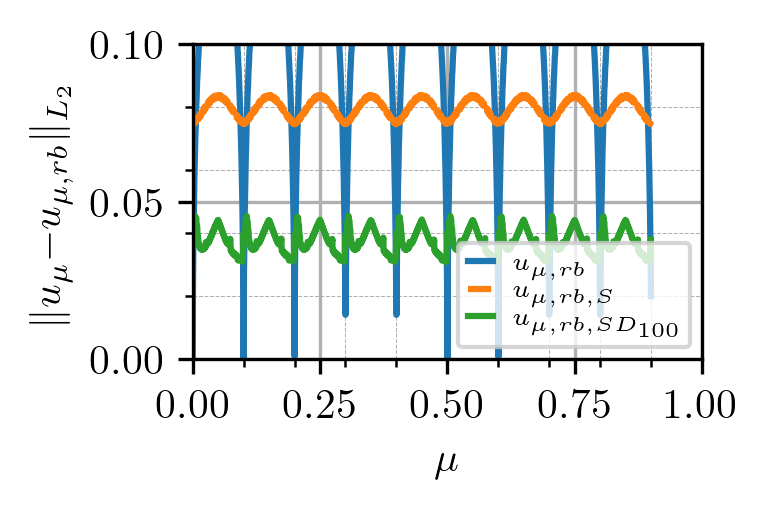

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


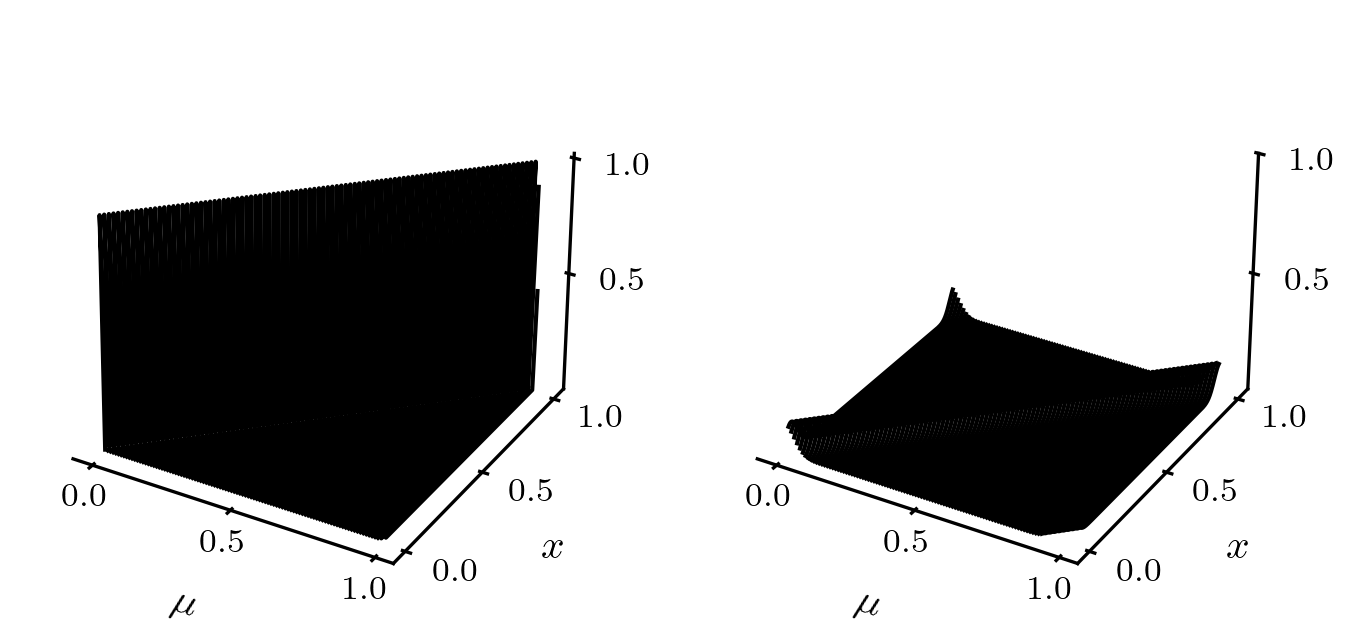

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


average improvement (250 iterations): 9.52


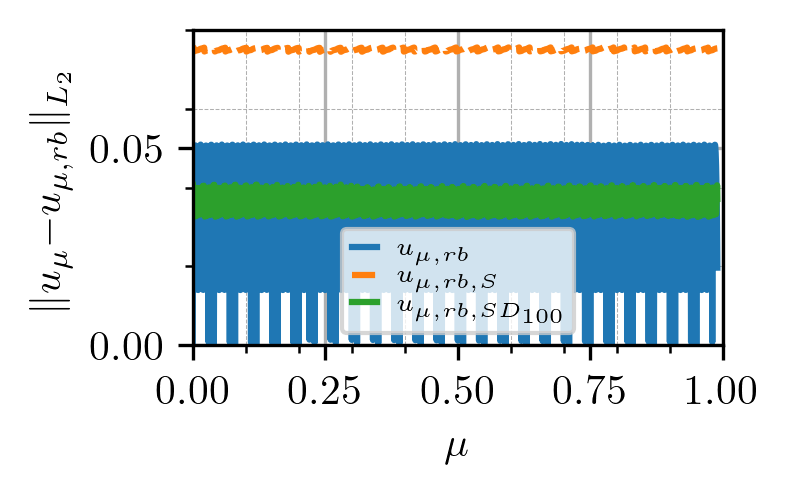

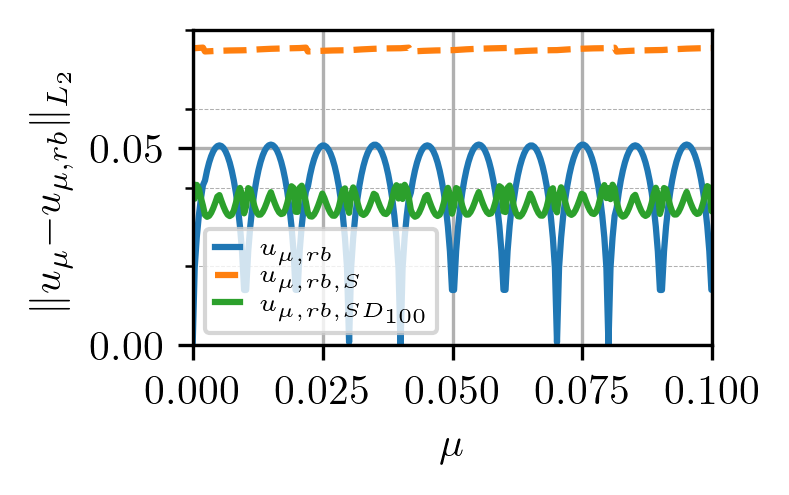

100
250, 0.00550000, 5.00000000, 0.03858684, 0.04202513, 0.05558337, 44.0475
250, 0.00850000, 5.00000000, 0.03858684, 0.04975479, 0.05453106, 41.3204
250, 0.00250000, 5.00000000, 0.03858684, 0.03588416, 0.04389094, 13.7459
250, 0.00550000, 8.33333333, 0.03858684, 0.04202513, 0.05502491, 42.6002
250, 0.00550000, 1.66666667, 0.03858684, 0.04202513, 0.04366600, 13.1629
250, 0.00850000, 1.66666667, 0.03858684, 0.04975479, 0.05292244, 37.1515
250, 0.00250000, 1.66666667, 0.03858684, 0.03588416, 0.04791065, 24.1632
250, 0.00850000, 8.33333333, 0.03858684, 0.04975479, 0.05264993, 36.4453
250, 0.00250000, 8.33333333, 0.03858684, 0.03588416, 0.05219033, 35.2542
250, 0.00650000, 1.66666667, 0.03858684, 0.04464698, 0.04870452, 26.2205
250, 0.00450000, 1.66666667, 0.03858684, 0.03951755, 0.03437673, -10.9107
250, 0.00550000, 2.77777778, 0.03858684, 0.04202513, 0.05190012, 34.5021
250, 0.00550000, 0.55555556, 0.03858684, 0.04202513, 0.02731256, -29.2179
250, 0.00650000, 0.55555556, 0.03858684, 0.04

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


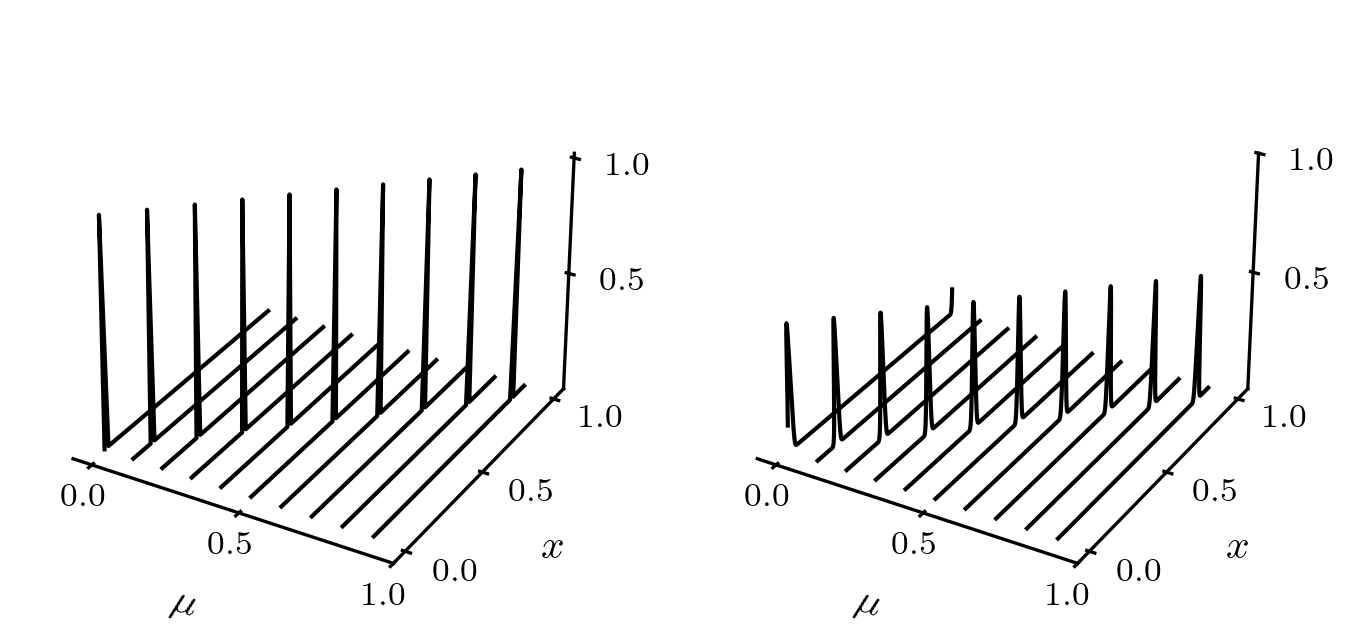

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


average improvement (250 iterations): -7.91


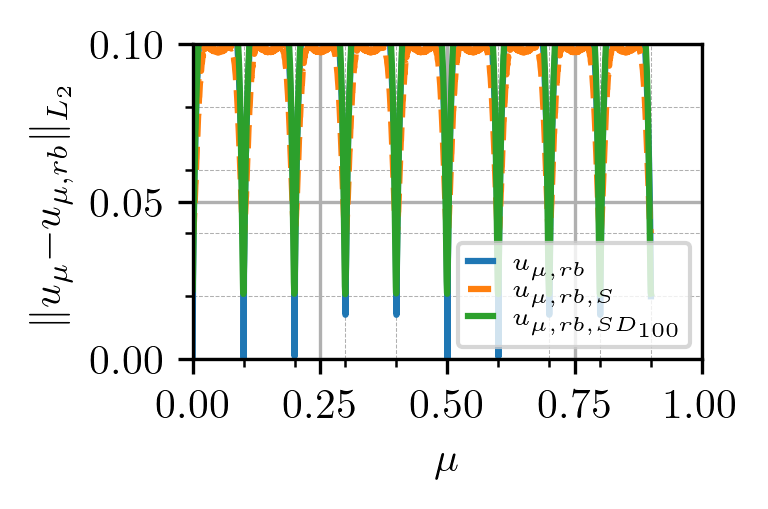

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


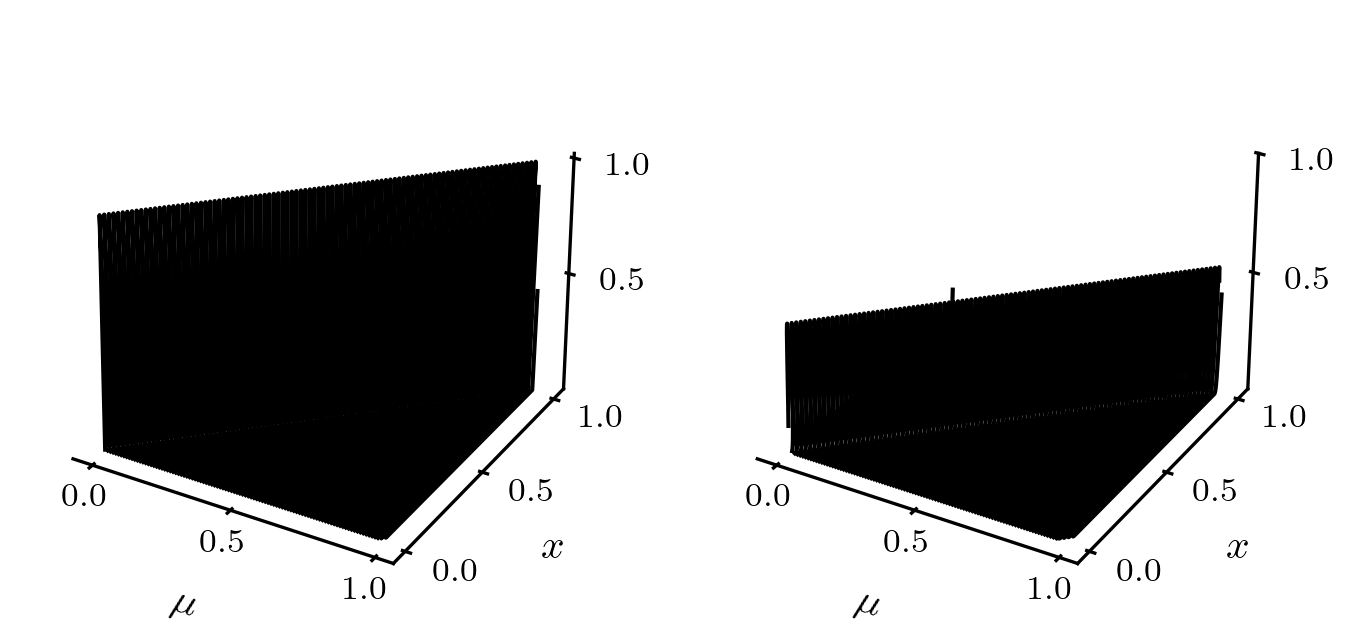

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


average improvement (250 iterations): 35.78


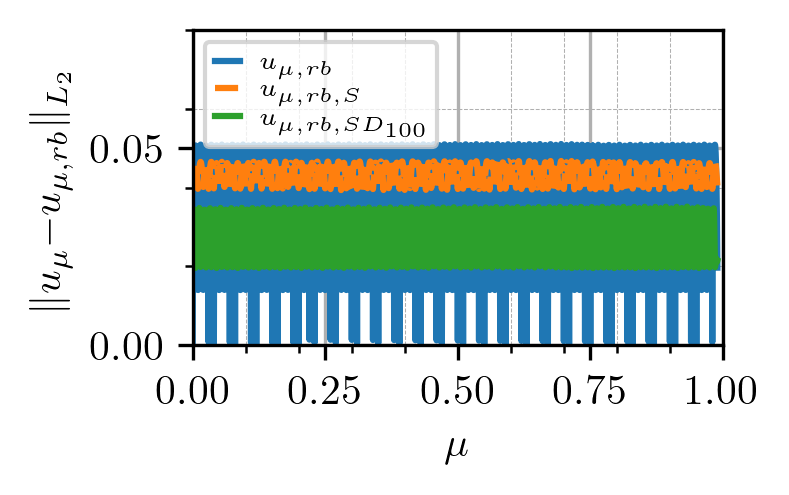

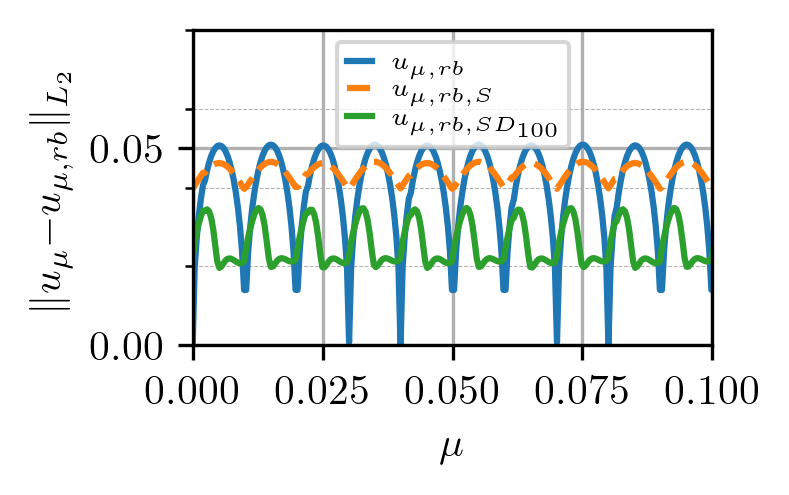

In [6]:
for rank in [10, 100]:
    print(rank)
    case["rank"] = rank
    case["n_train"] = rank
    parameters = optimize_hyperparameters(case)

    case["sigma"], case["c"] = parameters[0], parameters[1]
    #case["sigma"], case["c"] = 0.046817495544034825, 3.4777597632478527
    #case["sigma"], case["c"] = 0.046817495544034825, 3.4777597632478527
    for rank, ylim in zip([10, 100], (0.1, 0.08)):
        case["rank"] = rank
        case["n_train"] = rank
        mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
        mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=case["n_test"], **case)
        mu_val, X_val, X_val_s = make_data_rw(mu_train[0], mu_train[-1], n_samples=2500, **case)

        
        Fig3(x, mu_train, X_train, X_train_s)
    
        my_ROM = train_ROM_rw(mu_train, X_train)
        my_sROM = train_ROM_rw(mu_train, X_train_s)
    
        X_val_ROM = my_ROM.predict(mu_val).snapshots_matrix
        X_val_sROM, X_val_sROMs = get_predictions(my_sROM, mu_val, **case)
        
    
        # replace test with val
        mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
            X_val, X_val_ROM, X_val_sROM, X_val_sROMs
        )
    
        eROM = L2_error_rw(X_val_ROM, X_val)
        esROM = L2_error_rw(X_val_sROM, X_val)
        esROMs = L2_error_rw(X_val_sROMs, X_val)
        imp1 = 100 - np.mean(esROMs) / np.mean(eROM) * 100
        print("average improvement ({:.0f} iterations): {:.2f}".format(case["num_iter"], imp1))

        fig, ax = Fig6(mu_val, eROM, esROM, esROMs)
        ax.set_ylim(0, ylim)
        plt.show()

        if len(mu_train) > 10:
            fig, ax = Fig6(mu_val, eROM, esROM, esROMs)
            ax.set_xlim(mu_train[0], mu_train[10])
            ax.set_ylim(0, ylim)
            plt.show()
    
        #for (sigma, c) in zip((0.0468, 0.0471, 0.0106), (3.478, 0.9473, 1.1437)):


In [7]:
mu_train

array([[0.  ],
       [0.01],
       [0.02],
       [0.03],
       [0.04],
       [0.05],
       [0.06],
       [0.07],
       [0.08],
       [0.09],
       [0.1 ],
       [0.11],
       [0.12],
       [0.13],
       [0.14],
       [0.15],
       [0.16],
       [0.17],
       [0.18],
       [0.19],
       [0.2 ],
       [0.21],
       [0.22],
       [0.23],
       [0.24],
       [0.25],
       [0.26],
       [0.27],
       [0.28],
       [0.29],
       [0.3 ],
       [0.31],
       [0.32],
       [0.33],
       [0.34],
       [0.35],
       [0.36],
       [0.37],
       [0.38],
       [0.39],
       [0.4 ],
       [0.41],
       [0.42],
       [0.43],
       [0.44],
       [0.45],
       [0.46],
       [0.47],
       [0.48],
       [0.49],
       [0.5 ],
       [0.51],
       [0.52],
       [0.53],
       [0.54],
       [0.55],
       [0.56],
       [0.57],
       [0.58],
       [0.59],
       [0.6 ],
       [0.61],
       [0.62],
       [0.63],
       [0.64],
       [0.65],
       [0.

In [8]:
asd

NameError: name 'asd' is not defined

In [ ]:
n_x = 1000
n_train = 50
n_test = 10
num_iter1 = 100
#num_iter2 = 250
# num_iter3 = 1000
#num_iter4 = 2500

In [ ]:
rank = n_train
dx = 1 / n_x
shape = (n_x,)
clip = True

In [ ]:
x = np.linspace(0, 1, n_x, endpoint=False)
mu_train = np.linspace([0.0], [1.0], n_train, endpoint=False)
mu_test = np.linspace(mu_train[1], mu_train[2], n_test, endpoint=False)

g = rectangular_pulse

X_train = snapshots(g, x, mu_train)
X_test = snapshots(g, x, mu_test)

In [ ]:
#sigma, c = optimize_hyperparameters(x, mu_train, mu_test, X_train, X_test, shape, num_iter2, clip, rank)
rank, sigma, c = 10, 0.046817495544034825, 3.4777597632478527  # -77.5, num_iter2=250, n_test=10
rank, sigma, c = 20, 0.04709477073255084, 0.9473123624789438  # -64.5, num_iter2=250, n_test=10
rank, sigma, c = 50, 0.010637015820358114, 1.1437423194705931  # -53.5667, num_iter2=250, n_test=10

In [ ]:
X_train_s = smoothen(X_train, sigma / dx, x.shape, truncate=12)
X_test_s = smoothen(X_test, sigma / dx, x.shape, truncate=12)

Fig3(x, mu_train, X_train, X_train_s)

In [ ]:
def Fig6(mu_val, eROM, esROM, esROMs):
    fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
    ax.plot(mu_val, eROM, "C0-", label=r"$u_{\mu, rb}$")
    ax.plot(mu_val, esROM, "C1--", label=r"$u_{\mu, rb, S}$")
    ax.plot(mu_val, esROMs, "C2-", label=r"$u_{\mu, rb, SD_{100}}$")
#    ax.plot(mu_val, esROMs2, "C3-", label="$u_{\mu, rb, SD_{1000}}$")
    plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb}}\|_{L_2}$")
    plt.xlabel(r"$\mu$")
    plt.legend()
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
    plt.grid(True, which="minor", linestyle="--", lw=0.25)
    plt.grid(True, which="major", linestyle="-")
    plt.xlim(0, 1)
    # plt.show()
    return fig, ax

In [ ]:
for rank, ylim in zip([10, 20, 50], (0.4, 0.3, 0.2)):
    for (sigma, c) in zip((0.0468, 0.0471, 0.0106), (3.478, 0.9473, 1.1437)):
        print(rank, sigma, c)
        mu_train = np.linspace([0.0], [1.0], rank, endpoint=False)
        X_train = snapshots(g, x, mu_train)
        X_train_s = smoothen(X_train, sigma / dx, x.shape, truncate=12)

        mu_val = x.copy()
        interpolatable = (mu_train[0] < mu_val) & (mu_val < mu_train[-1])
        mu_val = mu_val[interpolatable][:, None]
        X_val = snapshots(g, x, mu_val)
        X_val_s = smoothen(X_val, sigma / dx, x.shape, truncate=12)
        
        Fig3(x, mu_train, X_train, X_train_s)

        print("build ROM and predict")
        standard_rom = train_ROM(mu_train, X_train, rank=rank)
        smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
        X_test_ROM = standard_rom.predict(mu_test).snapshots_matrix.T
        X_val_ROM = standard_rom.predict(mu_val).snapshots_matrix.T
        X_test_sROM = smooth_rom.predict(mu_test).snapshots_matrix.T
        X_val_sROM = smooth_rom.predict(mu_val).snapshots_matrix.T


        print("model performance validation")
        X_val_sROMs = post_process(
            x, X_val_sROM, sigma, c, mu_val, mu_train, num_iter1, shape, clip=clip, progress=False
        )
#        X_val_sROMs2 = post_process(
#            x, X_val_sROM, sigma, c, mu_val, mu_train, num_iter2, shape, clip=clip, progress=True
#        )
        eROM = L2_error(X_val_ROM, X_val)
        esROM = L2_error(X_val_sROM, X_val)
        esROMs = L2_error(X_val_sROMs, X_val)
#        esROMs2 = L2_error(X_val_sROMs2, X_val)
        imp1 = 100 - np.mean(esROMs) / np.mean(eROM) * 100
#        imp2 = 100 - np.mean(esROMs2) / np.mean(eROM) * 100
        print("average improvement ({:.0f} iterations): {:.2f}".format(num_iter1, imp1))
#        print("average improvement ({:.0f} iterations): {:.2f}".format(num_iter2, imp2))

        fig, ax = Fig6(mu_val, eROM, esROM, esROMs)
        ax.set_ylim(0, ylim)